## Task  - GMMs

GMMs are a probabilistic model for representing normally distributed subpopulations within an overall population. They assume that the data is generated from a mixture of several Gaussian distributions with unknown parameters. The goal is to estimate the parameters of these Gaussian distributions (mean, covariance) and the mixing coefficients.

* Implement the GMM logic using the class structure below. The GMM class should be able to fit to data using the EM algorithm. **(RESULT)**
* Visualize the performance of your GMM implementation on synthetic data, i.e., generate data from known Gaussian distributions and show how well your GMM can recover the original parameters. **(RESULT)**

In [ ]:
import numpy as np
from scipy.stats import multivariate_normal
import matplotlib.pyplot as plt

In [ ]:
class GMM:
    """
    Gaussian Mixture Model implementation using Expectation-Maximization algorithm.
    """
    def __init__(self):
        self.n_components = 3
        self.max_iter = 200
        self.tol = 1e-6
        self.reg_covar = 1e-6
        self.weights_ = None
        self.means_ = None
        self.covariances_ = None
        self.log_likelihoods_ = []

    def _gaussian_pdf(self, X, mean, cov):
        rv = multivariate_normal(mean=mean, cov=cov, allow_singular=True)
        return rv.pdf(X)

    def _e_step(self, X):
        n_samples, _ = X.shape
        K = self.n_components
        resp = np.zeros((n_samples, K))
        for k in range(K):
            pdf = self._gaussian_pdf(X, self.means_[k], self.covariances_[k])
            resp[:, k] = self.weights_[k] * pdf
        row_sums = resp.sum(axis=1, keepdims=True)
        row_sums[row_sums == 0] = 1e-16
        resp /= row_sums
        return resp

    def _m_step(self, X, responsibilities):
        n_samples, dim = X.shape
        K = self.n_components
        Nk = responsibilities.sum(axis=0)
        weights = Nk / n_samples
        means = np.zeros((K, dim))
        for k in range(K):
            if Nk[k] > 0:
                means[k] = (responsibilities[:, k][:, np.newaxis] * X).sum(axis=0) / Nk[k]
            else:
                means[k] = X[np.random.choice(n_samples)]
        covariances = np.zeros((K, dim, dim))
        for k in range(K):
            diff = X - means[k]
            if Nk[k] > 0:
                cov = (responsibilities[:, k][:, np.newaxis, np.newaxis] *
                       np.einsum('ni,nj->nij', diff, diff)).sum(axis=0) / Nk[k]
            else:
                cov = np.cov(X, rowvar=False)
            cov += np.eye(dim) * self.reg_covar
            covariances[k] = cov
        self.weights_ = weights
        self.means_ = means
        self.covariances_ = covariances

    def _compute_lower_bound(self, X):
        n_samples = X.shape[0]
        K = self.n_components
        total = np.zeros(n_samples)
        for k in range(K):
            pdf = self._gaussian_pdf(X, self.means_[k], self.covariances_[k])
            total += self.weights_[k] * pdf
        total[total == 0] = 1e-16
        return np.sum(np.log(total))

    def fit(self, X):
        X = np.asarray(X)
        n_samples, dim = X.shape
        K = int(self.n_components)
        self.weights_ = np.ones(K) / K
        idx = np.random.choice(n_samples, K, replace=False)
        self.means_ = X[idx].astype(float)
        sample_cov = np.cov(X, rowvar=False)
        self.covariances_ = np.array([sample_cov + np.eye(dim) * self.reg_covar for _ in range(K)])
        prev_ll = None
        self.log_likelihoods_ = []
        for i in range(self.max_iter):
            responsibilities = self._e_step(X)
            self._m_step(X, responsibilities)
            ll = self._compute_lower_bound(X)
            self.log_likelihoods_.append(ll)
            if prev_ll is not None and abs(ll - prev_ll) < self.tol:
                break
            prev_ll = ll
        return self

    def predict(self, X):
        X = np.asarray(X)
        resp = np.zeros((X.shape[0], self.n_components))
        for k in range(self.n_components):
            pdf = self._gaussian_pdf(X, self.means_[k], self.covariances_[k])
            resp[:, k] = self.weights_[k] * pdf
        row_sums = resp.sum(axis=1, keepdims=True)
        row_sums[row_sums == 0] = 1e-16
        resp /= row_sums
        return resp.argmax(axis=1)


True weights: [0.4  0.35 0.25]
Recovered weights: [0.4163 0.3287 0.255 ]

True means:
 [[ 0  0]
 [ 4  4]
 [-3  5]]
Recovered means:
 [[-0.0151  0.1037]
 [ 3.946   4.0698]
 [-2.9371  5.0297]]

True covariances:
 [[[ 0.8  0.2]
  [ 0.2  0.7]]

 [[ 0.6 -0.2]
  [-0.2  0.5]]

 [[ 0.9  0. ]
  [ 0.   0.4]]]
Recovered covariances:
 [[[ 0.6843  0.1504]
  [ 0.1504  0.7047]]

 [[ 0.5763 -0.2239]
  [-0.2239  0.4994]]

 [[ 0.8004  0.0337]
  [ 0.0337  0.4881]]]


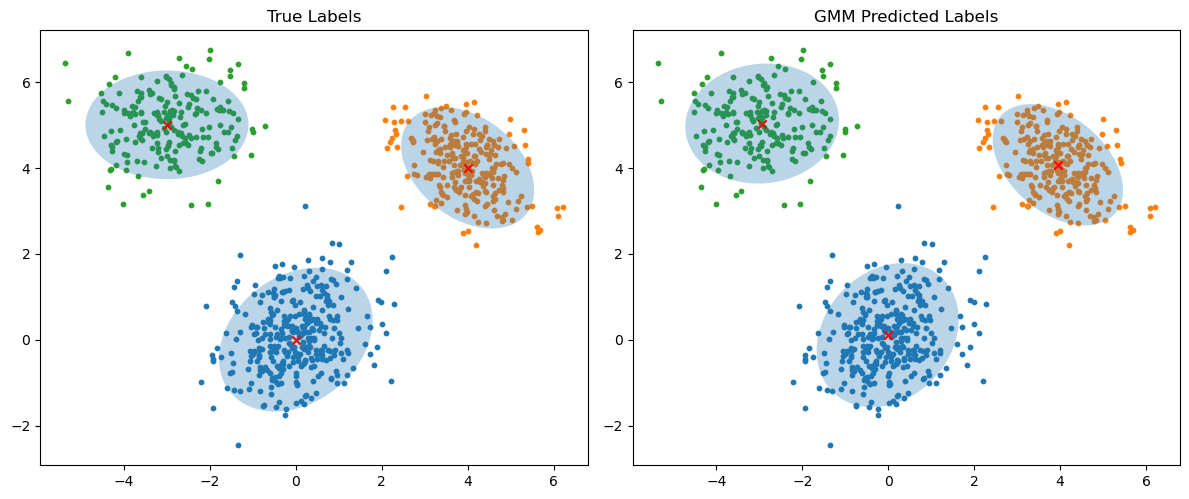

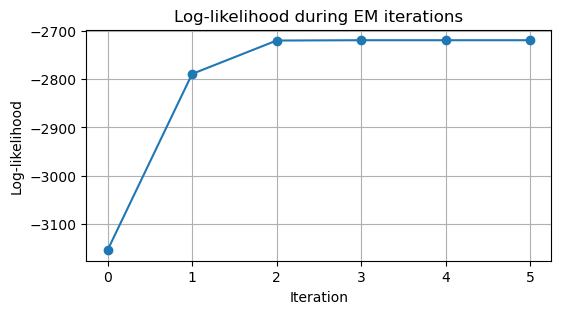

In [ ]:
 from matplotlib.patches import Ellipse

def plot_cov_ellipse(ax, mean, cov, n_std=2.0):
    eigvals, eigvecs = np.linalg.eigh(cov)
    order = eigvals.argsort()[::-1]
    eigvals, eigvecs = eigvals[order], eigvecs[:, order]
    angle = np.degrees(np.arctan2(eigvecs[1, 0], eigvecs[0, 0]))
    width, height = 2 * n_std * np.sqrt(eigvals)
    ell = Ellipse(xy=mean, width=width, height=height, angle=angle, alpha=0.3)
    ax.add_patch(ell)
    ax.scatter(mean[0], mean[1], marker='x', color='red')

# Generate synthetic data
np.random.seed(42)
true_means = np.array([[0, 0], [4, 4], [-3, 5]])
true_covs = np.array([[[0.8, 0.2], [0.2, 0.7]], [[0.6, -0.2], [-0.2, 0.5]], [[0.9, 0.0], [0.0, 0.4]]])
true_weights = np.array([0.4, 0.35, 0.25])
n_samples = 800

components = np.random.choice(len(true_weights), size=n_samples, p=true_weights)
X = np.zeros((n_samples, 2))
y_true = np.zeros(n_samples, dtype=int)
for i, k in enumerate(components):
    X[i] = np.random.multivariate_normal(mean=true_means[k], cov=true_covs[k])
    y_true[i] = k

# Fit GMM
gmm = GMM()
gmm.n_components = 3
gmm.max_iter = 300
gmm.fit(X)
y_pred = gmm.predict(X)

# Print results
print("True weights:", np.round(true_weights, 4))
print("Recovered weights:", np.round(gmm.weights_, 4))
print("\nTrue means:\n", np.round(true_means, 4))
print("Recovered means:\n", np.round(gmm.means_, 4))
print("\nTrue covariances:\n", np.round(true_covs, 4))
print("Recovered covariances:\n", np.round(gmm.covariances_, 4))

# Plot results
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ax = axes[0]
ax.set_title("True Labels")
for k in range(len(true_weights)):
    pts = X[y_true == k]
    ax.scatter(pts[:, 0], pts[:, 1], s=10)
    plot_cov_ellipse(ax, true_means[k], true_covs[k])
ax.set_aspect('equal', 'box')

ax = axes[1]
ax.set_title("GMM Predicted Labels")
for k in range(gmm.n_components):
    pts = X[y_pred == k]
    ax.scatter(pts[:, 0], pts[:, 1], s=10)
    plot_cov_ellipse(ax, gmm.means_[k], gmm.covariances_[k])
ax.set_aspect('equal', 'box')
plt.tight_layout()
plt.show()

# Log-likelihood plot
plt.figure(figsize=(6,3))
plt.plot(gmm.log_likelihoods_, marker='o')
plt.title("Log-likelihood during EM iterations")
plt.xlabel("Iteration")
plt.ylabel("Log-likelihood")
plt.grid(True)
plt.show()


## Task 2.2.2 - Regularizing the GMM

* Implement regularization techniques for the covariance matrices to towards the assumption of uncorrelated input features. Extend the existing `GMM` class above.

In [ ]:
class RegularizedGMM(GMM):
    """
    Extended GMM with covariance regularization toward diagonal (uncorrelated features).
    Inherits from the original GMM class.
    """

    def __init__(self, reg_strength=0.1):
        super().__init__()
        self.reg_strength = reg_strength  # 0 = no regularization, 1 = fully diagonalize

    def _regularize_covariance(self, cov):
        """
        Blend covariance matrix toward its diagonal version.
        reg_strength=0 keeps original covariance, reg_strength=1 keeps only diagonal.
        """
        diag_cov = np.diag(np.diag(cov))
        return (1 - self.reg_strength) * cov + self.reg_strength * diag_cov

    def _m_step(self, X, responsibilities):
        """Override the M-step to include covariance regularization."""
        n_samples, dim = X.shape
        K = self.n_components
        Nk = responsibilities.sum(axis=0)
        weights = Nk / n_samples
        means = np.zeros((K, dim))
        for k in range(K):
            if Nk[k] > 0:
                means[k] = (responsibilities[:, k][:, np.newaxis] * X).sum(axis=0) / Nk[k]
            else:
                means[k] = X[np.random.choice(n_samples)]

        covariances = np.zeros((K, dim, dim))
        for k in range(K):
            diff = X - means[k]
            if Nk[k] > 0:
                cov = (responsibilities[:, k][:, np.newaxis, np.newaxis] *
                       np.einsum('ni,nj->nij', diff, diff)).sum(axis=0) / Nk[k]
            else:
                cov = np.cov(X, rowvar=False)

            # Add numerical regularization
            cov += np.eye(dim) * self.reg_covar
            # Blend toward diagonal to remove correlation
            cov = self._regularize_covariance(cov)
            covariances[k] = cov

        self.weights_ = weights
        self.means_ = means
        self.covariances_ = covariances


Recovered weights (Regularized): [0.4161 0.3289 0.255 ]
Recovered means (Regularized):
 [[-0.0159  0.1031]
 [ 3.9453  4.069 ]
 [-2.9371  5.0297]]
Recovered covariances (Regularized):
 [[[ 0.6829  0.0447]
  [ 0.0447  0.7036]]

 [[ 0.5773 -0.0667]
  [-0.0667  0.5009]]

 [[ 0.8006  0.0101]
  [ 0.0101  0.4881]]]


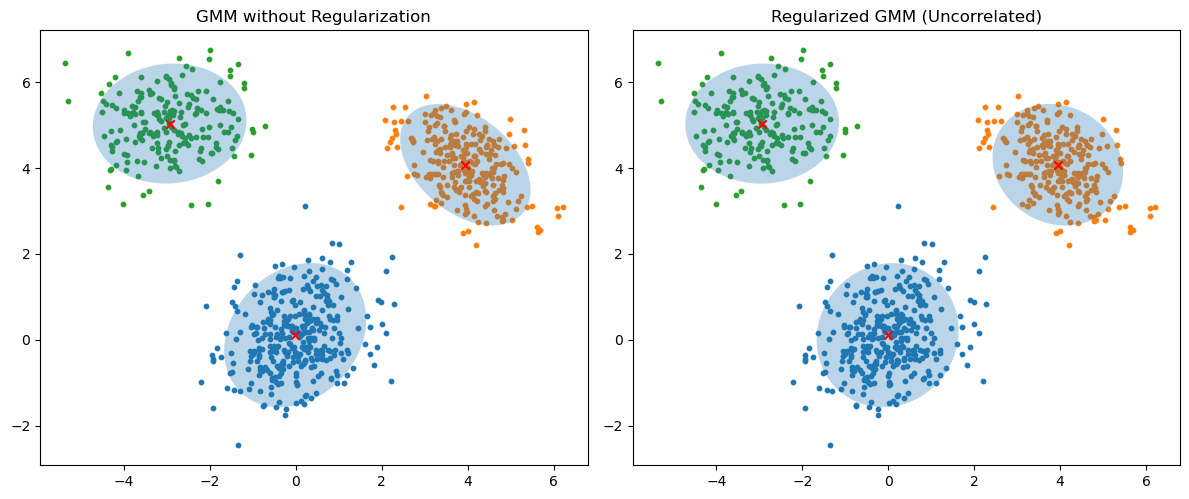

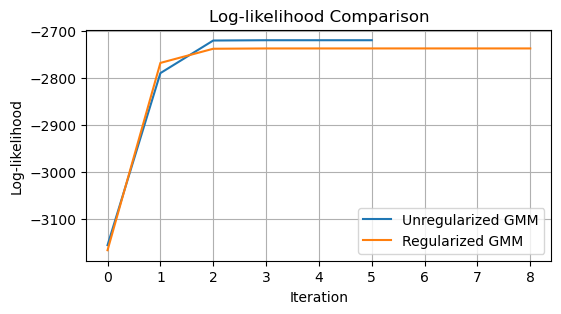

In [ ]:
# Generate the same synthetic data from before
np.random.seed(42)
true_means = np.array([[0, 0], [4, 4], [-3, 5]])
true_covs = np.array([[[0.8, 0.2], [0.2, 0.7]], [[0.6, -0.2], [-0.2, 0.5]], [[0.9, 0.0], [0.0, 0.4]]])
true_weights = np.array([0.4, 0.35, 0.25])
n_samples = 800

components = np.random.choice(len(true_weights), size=n_samples, p=true_weights)
X = np.zeros((n_samples, 2))
for i, k in enumerate(components):
    X[i] = np.random.multivariate_normal(mean=true_means[k], cov=true_covs[k])

# Fit Regularized GMM
reg_gmm = RegularizedGMM(reg_strength=0.7)  # stronger regularization (closer to diagonal)
reg_gmm.n_components = 3
reg_gmm.max_iter = 300
reg_gmm.fit(X)
y_reg = reg_gmm.predict(X)

# Print results
print("Recovered weights (Regularized):", np.round(reg_gmm.weights_, 4))
print("Recovered means (Regularized):\n", np.round(reg_gmm.means_, 4))
print("Recovered covariances (Regularized):\n", np.round(reg_gmm.covariances_, 4))

# Plot results
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ax = axes[0]
ax.set_title("GMM without Regularization")
y_pred = gmm.predict(X)
for k in range(gmm.n_components):
    pts = X[y_pred == k]
    ax.scatter(pts[:, 0], pts[:, 1], s=10)
    plot_cov_ellipse(ax, gmm.means_[k], gmm.covariances_[k])
ax.set_aspect('equal', 'box')

ax = axes[1]
ax.set_title("Regularized GMM (Uncorrelated)")
for k in range(reg_gmm.n_components):
    pts = X[y_reg == k]
    ax.scatter(pts[:, 0], pts[:, 1], s=10)
    plot_cov_ellipse(ax, reg_gmm.means_[k], reg_gmm.covariances_[k])
ax.set_aspect('equal', 'box')
plt.tight_layout()
plt.show()

# Compare log-likelihoods
plt.figure(figsize=(6,3))
plt.plot(gmm.log_likelihoods_, label='Unregularized GMM')
plt.plot(reg_gmm.log_likelihoods_, label='Regularized GMM')
plt.title("Log-likelihood Comparison")
plt.xlabel("Iteration")
plt.ylabel("Log-likelihood")
plt.legend()
plt.grid(True)
plt.show()
